# Time evolution — scalar diagnostics + Δσ_zz profile

Broadens the §10 time loop from `cerpa_single_step.ipynb`. Per timestep, records:

| symbol | meaning | shape |
|---|---|---|
| `t_yr` | model time | scalar |
| `tloc`, `xi_loc` | trench column, first isostatic column | scalars |
| `Fd_xT` | $F_D(x_T) = \int(\tau_{xx}-\tau_{zz})\,dz$ at the trench | scalar |
| `V_xT` | $V(x_T) = \int\tau_{xz}\,dz$ at the trench | scalar |
| `w_T` | $\mathrm{fs}(x_I) - \mathrm{fs}(x_T)$ — topographic recovery between the two columns | scalar |
| `delta_Fd` | $F_D(x_I) - F_D(x_T)$ — column difference of the deviatoric resultant | scalar |
| `delta_GPE` | $\mathrm{GPE}^*(x_I) - \mathrm{GPE}^*(x_T)$ where $\mathrm{GPE}^* = -\int\sigma_{zz}\,dz$ | scalar |
| `delta_sig_zz_z` | $\sigma_{zz}(x_I, z) - \sigma_{zz}(x_T, z)$ — full depth profile | (nz,) |

Conventions match the rest of the repo: x rightward, z downward, model mirrored along x at extraction so subduction is right-to-left.

Outputs are saved to `outputs/time_evolution_<MODEL>.npz`.

## 1. Setup & imports

In [15]:
import numpy as np
import glob
import natsort
import matplotlib.pyplot as plt
import pyvista as pv
import warnings, logging, gc
from pathlib import Path
from scipy.integrate import cumulative_trapezoid
from scipy.ndimage import gaussian_filter1d

pv.set_error_output_file(Path('/tmp/vtk_errors.log'))
logging.getLogger('pyvista').setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore', message='The VTK reader .*vtkXMLPUnstructuredGridReader.*')

plt.rcParams.update({'mathtext.fontset': 'cm', 'font.family': 'serif'})

## 2. Configuration

Same setup conventions as the other Cerpa notebooks. `MIRROR_X = True` mirrors the model along x so subduction matches MDOODZ orientation.

In [50]:
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY = 'WAL'

DX        = 200.0
Z_MAX     = 100_000.0
Y_SURFACE = 2_900_000.0

# Mirror flag and derived directional constants
MIRROR_X        = True
SUBDUCTING_SIDE = 'right' if MIRROR_X else 'left'
SEAWARD_SIGN    = +1     if MIRROR_X else -1

# Isostatic-column picker parameters
BUFFER_KM    = 30           # skip this much of the bend right next to the trench
WINDOW_KM    = 500          # search window seaward of the trench
REGIONAL_REF_KM = 500       # offset of the 'regional' reference column from the trench

fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']
pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
print(f"Model {MODEL_KEY!r}: {len(pvtu_files)} PVTU files in {fbase}")
print(f"MIRROR_X = {MIRROR_X}  ->  SUBDUCTING_SIDE = {SUBDUCTING_SIDE!r}, SEAWARD_SIGN = {SEAWARD_SIGN:+d}")

Model 'WAL': 41 PVTU files in /Users/DSAND/DATA/numerical_models/OUTPUTS/WAL_RefModel/
MIRROR_X = True  ->  SUBDUCTING_SIDE = 'right', SEAWARD_SIGN = +1


## 3. Helpers

- `get_field(name)` — reshapes a sampled VTK array onto the regular grid.
- `mirror_fields_in_x(...)` — applies the x-mirror with sign flips on the off-diagonal stress and x-velocity.
- `pick_trench_3step(...)` — same picker as the other notebooks (pressure → velocity → directional pressure).
- `find_first_isostatic_column(...)` — walks seaward from the trench and returns the index of the first column whose free-surface elevation has recovered to the regional reference.

In [51]:
def get_field(name):
    f = interp[name].reshape((nx_pv, nz_pv), order='F')
    f[~valid] = np.nan
    return f.T  # (z, x)


def mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz):
    # Mirror all 2D fields along x so subduction matches MDOODZ orientation.
    # Under x -> -x: scalars/diagonals flip in space only; off-diagonal stress
    # and vx pick up an additional sign flip.
    flip = lambda a: np.flip(a, axis=1)
    return (flip(p), flip(txx), flip(tzz), -flip(txz),
            flip(T), flip(fs), -flip(vx), flip(vz))

In [52]:
def pick_trench_3step(x, z, p, vx,
        p_depth_m=0.0, vx_depth_m=5_000.0,
        Wp1_km=800.0, Wv_km=800.0, Wp3_km=300.0,
        expected_offset_km=50.0, smooth_km=20.0,
        subducting_side='left'):
    iz_p  = 0 if p_depth_m == 0.0 else int(np.argmin(np.abs(z - p_depth_m)))
    iz_vx = int(np.argmin(np.abs(z - vx_depth_m)))
    p_row, vx_row = p[iz_p, :].copy(), vx[iz_vx, :].copy()

    j0 = int(np.nanargmin(p_row));  x_p0 = float(x[j0])

    Wv = Wv_km * 1000.0
    in_v = (x >= x_p0 - Wv) & (x <= x_p0 + Wv)
    x_vw, vx_vw = x[in_v], vx_row[in_v]
    dx = np.median(np.diff(x))
    k = max(1, int((smooth_km*1000.0)/dx)); k += (k%2 == 0)
    vx_s = np.convolve(vx_vw, np.ones(k)/k, mode='same')
    s = np.sign(vx_s); s[s == 0] = np.nan
    cross = np.where(np.isfinite(s[:-1]) & np.isfinite(s[1:]) & (s[:-1]*s[1:] < 0))[0]
    if cross.size == 0:
        x_v = float(x_vw[int(np.nanargmin(np.abs(vx_s)))])
    else:
        xc = []
        for ii in cross:
            x1, x2 = x_vw[ii], x_vw[ii+1]
            v1, v2 = vx_s[ii], vx_s[ii+1]
            xc.append(x1 - v1 * (x2 - x1) / (v2 - v1))
        xc = np.array(xc)
        # Pick velocity zero-crossing on the subducting-plate side
        # (rightmost when slab descends right, leftmost when it descends left).
        x_v = float(np.max(xc) if subducting_side == 'right' else np.min(xc))

    Wp3 = Wp3_km * 1000.0
    expected_offset = expected_offset_km * 1000.0
    if subducting_side == 'left':
        mask = (x < x_v) & (x >= x_v - Wp3)
        x_expected = x_v - expected_offset
    else:
        mask = (x > x_v) & (x <= x_v + Wp3)
        x_expected = x_v + expected_offset
    xw, pw = x[mask], p_row[mask]
    good = np.isfinite(pw); xw, pw = xw[good], pw[good]
    is_min = (pw[1:-1] < pw[:-2]) & (pw[1:-1] < pw[2:])
    idx = np.where(is_min)[0] + 1
    if idx.size == 0:
        trench_x = float(xw[int(np.argmin(pw))])
    else:
        j = idx[np.argmin(np.abs(xw[idx] - x_expected))]
        trench_x = float(xw[j])

    return trench_x, dict(x_p0=x_p0, x_v=x_v)


In [53]:
def find_first_isostatic_column(x, fs_top, tloc, tindx, DX,
                                 buffer_km=30, window_km=500,
                                 regional_ref_km=500, seaward_sign=+1):
    # Walk seaward of the trench (with a buffer) and return the first index
    # where the free-surface elevation has recovered to the regional reference
    # taken `regional_ref_km` seaward of the trench.
    i_far = int(np.argmin(np.abs(x - (tloc + seaward_sign * regional_ref_km * 1000.0))))
    target = float(fs_top[i_far])

    buffer_grid = int(buffer_km * 1000.0 / DX)
    window_grid = int(window_km * 1000.0 / DX)
    i_start = max(0, min(len(x)-1, tindx + seaward_sign * buffer_grid))
    i_end   = max(0, min(len(x)-1, tindx + seaward_sign * window_grid))
    step    = int(np.sign(seaward_sign)) or +1

    for i in range(i_start, i_end, step):
        if fs_top[i] >= target:
            return i, i_far
    return i_end, i_far

## 4. Time loop

For each PVTU snapshot: load → mirror → pick trench → find first isostatic column → compute the column quantities → record scalars + the Δσ_zz depth profile.

In [54]:
SECONDS_PER_YEAR = 31_557_600.0

# Load-or-compute guard.  Set FORCE_RECOMPUTE = True to ignore any cached
# npz at NPZ_PATH and rerun the time loop.  Old cached npz files that
# pre-date the `z_iso` column also trigger a recompute.
NPZ_PATH        = Path('outputs') / f'time_evolution_{MODEL_KEY}.npz'
FORCE_RECOMPUTE = False

# Isotherm whose depth we track at the trench column (in Kelvin; PVTU
# field is in K with T_surface = 273, T_mantle = 1573).
T_ISO_K = 900.0 + 273.15        # =
print(T_ISO_K )

1173.15


In [55]:
_from_cache = False
if NPZ_PATH.exists() and not FORCE_RECOMPUTE:
    d = np.load(NPZ_PATH)
    if 'z_iso' in d.files:
        z_axis          = d['z']
        delta_sig_zz_zt = d['delta_sig_zz_zt']
        records = {k: d[k] for k in d.files if k not in ('z', 'delta_sig_zz_zt')}
        _from_cache = True
        print(f'loaded cache: {NPZ_PATH}  ({len(records["snapshot"])} snapshots)')
    else:
        print(f'cache at {NPZ_PATH} is missing newer fields; recomputing')

if not _from_cache:
    records = dict(
        snapshot=[], t_yr=[], tloc=[], xi_loc=[],
        Fd_xT=[], V_xT=[], w_T=[],
        delta_Fd=[], delta_GPE=[],
        z_iso=[],
    )
    delta_sig_zz_z_list = []
    z_axis = None

    for i, ff in enumerate(pvtu_files[::2]):
        if i == 0:
            continue

        vtk_data = pv.read(ff)
        vtk_data.point_data['p']   = vtk_data['NormalSP::Pressure']
        vtk_data.point_data['txx'] = vtk_data['NormalSP::Stress'][:, 0]
        vtk_data.point_data['tzz'] = vtk_data['NormalSP::Stress'][:, 4]
        vtk_data.point_data['txz'] = -vtk_data['NormalSP::Stress'][:, 1]
        vtk_data.point_data['T']   = vtk_data['NormalSP::Temperature']
        vtk_data.point_data['fs']  = vtk_data['NormalSP::FreeSurface']
        vel = vtk_data['NormalSP::Velocity'] / 3.17098e-10
        vtk_data.point_data['vx']  = vel[:, 0]
        vtk_data.point_data['vy']  = vel[:, 1]

        t_yr = float(np.asarray(vtk_data['NormalSP::Time']).flat[0]) / SECONDS_PER_YEAR

        x_min, x_max, _, _, _, _ = vtk_data.bounds
        nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
        x = x_min + (np.arange(nx) + 0.5) * DX
        z = (np.arange(nz) + 0.5) * DX
        X, Z = np.meshgrid(x, z, indexing='xy')
        Y = Y_SURFACE - Z
        grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
        interp = grid.sample(vtk_data)
        nx_pv, nz_pv, _ = interp.dimensions
        valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)

        p   = get_field('p')
        txx = get_field('txx')
        tzz = get_field('tzz')
        txz = get_field('txz')
        T   = get_field('T')
        fs  = get_field('fs')
        vx  = get_field('vx')
        vz  = -get_field('vy')

        if MIRROR_X:
            p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)

        if z_axis is None:
            z_axis = z.copy()

        try:
            tloc, _ = pick_trench_3step(
                x, z, p, vx,
                vx_depth_m=2000, Wp1_km=800, Wv_km=800, Wp3_km=500,
                smooth_km=30, subducting_side=SUBDUCTING_SIDE,
            )
        except Exception as e:
            print(f'  [{i}] picker failed: {e}; skipping')
            continue
        tindx = int(np.argmin(np.abs(x - tloc)))

        xi_indx, _ = find_first_isostatic_column(
            x, fs[0, :], tloc, tindx, DX,
            buffer_km=BUFFER_KM, window_km=WINDOW_KM,
            regional_ref_km=REGIONAL_REF_KM, seaward_sign=SEAWARD_SIGN,
        )
        xi_loc = float(x[xi_indx])

        Fd_x   = np.trapz(txx - tzz, z, axis=0)
        V_x    = np.trapz(txz, z, axis=0)
        GPE_x  = -np.trapz(-p + tzz, z, axis=0)
        sig_zz = -p + tzz

        Fd_xT     = float(Fd_x[tindx])
        V_xT      = float(V_x[tindx])
        w_T       = float(fs[0, xi_indx] - fs[0, tindx])
        delta_Fd  = float(Fd_x[xi_indx]  - Fd_x[tindx])
        delta_GPE = float(GPE_x[xi_indx] - GPE_x[tindx])

        delta_sig_zz_z = sig_zz[:, xi_indx] - sig_zz[:, tindx]

        # Depth to T_ISO_K at the trench column — first crossing from above.
        # T increases with depth in the lithosphere, so the sign of
        # (T_col - T_ISO_K) flips from negative to positive at the isotherm.
        T_col = T[:, tindx]
        diff  = T_col - T_ISO_K
        idx   = np.where(diff[:-1] * diff[1:] < 0)[0]
        if idx.size > 0:
            k = idx[0]
            z_iso = float(z[k] + (T_ISO_K - T_col[k]) * (z[k+1] - z[k])
                                  / (T_col[k+1] - T_col[k]))
        else:
            z_iso = float('nan')

        records['snapshot'].append(i)
        records['t_yr'].append(t_yr)
        records['tloc'].append(tloc)
        records['xi_loc'].append(xi_loc)
        records['Fd_xT'].append(Fd_xT)
        records['V_xT'].append(V_xT)
        records['w_T'].append(w_T)
        records['delta_Fd'].append(delta_Fd)
        records['delta_GPE'].append(delta_GPE)
        records['z_iso'].append(z_iso)
        delta_sig_zz_z_list.append(delta_sig_zz_z)

        del vtk_data, grid, interp, X, Y, Z, p, txx, tzz, txz, T, fs, vx, vz
        if i % 5 == 0:
            gc.collect()

    for k in records:
        records[k] = np.asarray(records[k])
    delta_sig_zz_zt = np.vstack(delta_sig_zz_z_list)

    print(f'\n[{MODEL_KEY}] processed {len(records["snapshot"])} snapshots')
    print(f'    t        = {records["t_yr"].min()/1e6:6.2f} -> {records["t_yr"].max()/1e6:6.2f} Myr')
    print(f'    F_D(x_T) = {records["Fd_xT"].min()*1e-12:+6.2f}  to {records["Fd_xT"].max()*1e-12:+6.2f} TN/m')
    print(f'    V(x_T)   = {records["V_xT"].min()*1e-12:+6.2f}  to {records["V_xT"].max()*1e-12:+6.2f} TN/m')
    print(f'    w_T      = {records["w_T"].min():+6.0f}  to {records["w_T"].max():+6.0f}  m')
    print(f'    Δ F_D    = {records["delta_Fd"].min()*1e-12:+6.2f}  to {records["delta_Fd"].max()*1e-12:+6.2f} TN/m')
    print(f'    Δ GPE*   = {records["delta_GPE"].min()*1e-12:+6.2f}  to {records["delta_GPE"].max()*1e-12:+6.2f} TN/m')
    print(f'    z_iso    = {np.nanmin(records["z_iso"])/1e3:6.1f}  to {np.nanmax(records["z_iso"])/1e3:6.1f} km   (T = {T_ISO_K-273.15:.0f}°C)')


cache at outputs/time_evolution_WAL.npz is missing newer fields; recomputing

[WAL] processed 20 snapshots
    t        =   4.01 ->  79.95 Myr
    F_D(x_T) =  -4.14  to  +0.05 TN/m
    V(x_T)   =  -1.73  to  -0.70 TN/m
    w_T      =  +1364  to  +2394  m
    Δ F_D    =  +1.54  to  +2.90 TN/m
    Δ GPE*   =  +1.64  to  +3.00 TN/m
    z_iso    =   50.3  to   77.4 km   (T = 900°C)


## 5. Persist to npz

In [60]:
outputs_dir = Path('outputs'); outputs_dir.mkdir(exist_ok=True)
npz_path = outputs_dir / f'time_evolution_{MODEL_KEY}.npz'

if not _from_cache:
    np.savez(npz_path, z=z_axis, delta_sig_zz_zt=delta_sig_zz_zt, **records)
    print(f'saved -> {npz_path}')
else:
    print(f'loaded from cache; save skipped ({npz_path.name})')


saved -> outputs/time_evolution_WAL.npz


## 6. Time-series plots

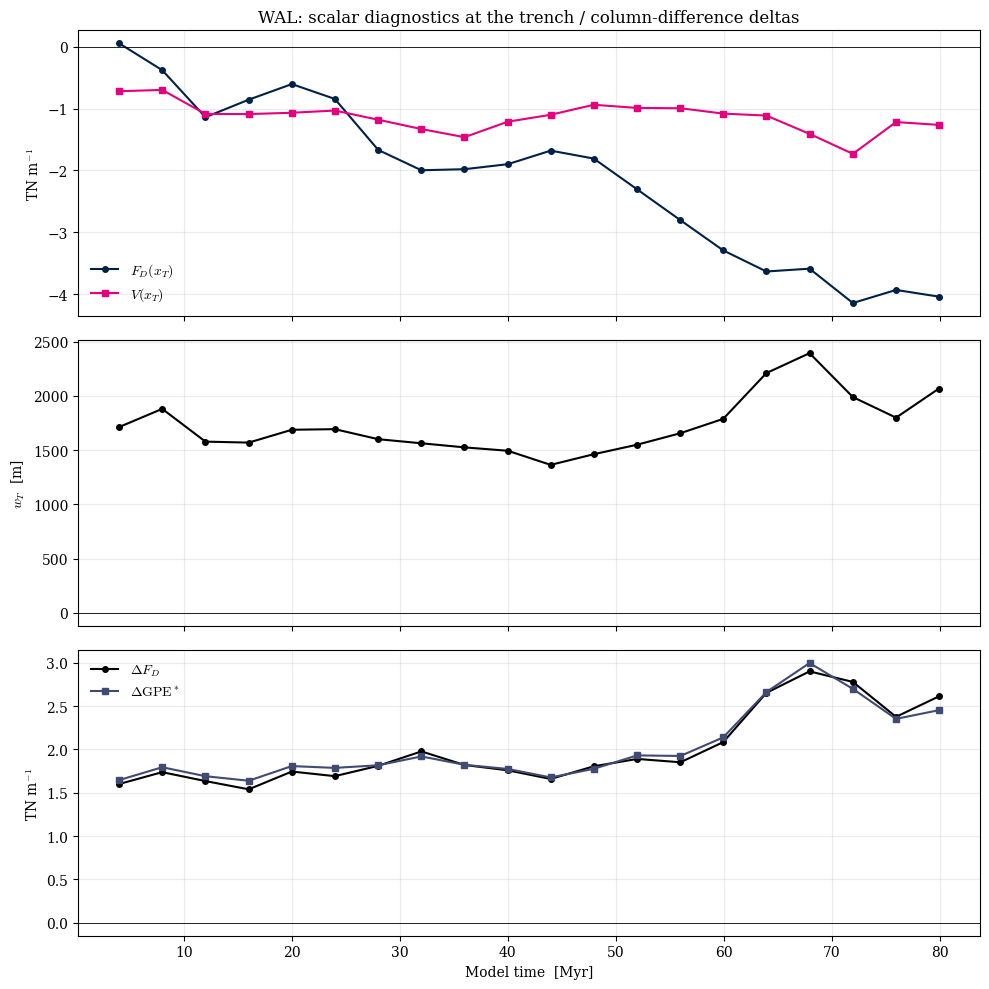

In [61]:
t_Myr = records['t_yr'] / 1e6

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# (a) F_D and V at the trench
axs[0].plot(t_Myr, records['Fd_xT'] * 1e-12, '-o', color='#002147', ms=4, lw=1.5,
            label=r'$F_D(x_T)$')
axs[0].plot(t_Myr, records['V_xT']  * 1e-12, '-s', color='#E5007D', ms=4, lw=1.5,
            label=r'$V(x_T)$')
axs[0].axhline(0, color='k', lw=0.6)
axs[0].set_ylabel(r'TN m$^{-1}$')
axs[0].legend(frameon=False, loc='best')
axs[0].grid(alpha=0.25)
axs[0].set_title(f'{MODEL_KEY}: scalar diagnostics at the trench / column-difference deltas')

# (b) trench depression
axs[1].plot(t_Myr, records['w_T'], '-o', color='k', ms=4, lw=1.5)
axs[1].axhline(0, color='k', lw=0.6)
axs[1].set_ylabel(r'$w_T$  [m]')
axs[1].grid(alpha=0.25)

# (c) deltas (column differences x_I - x_T)
axs[2].plot(t_Myr, records['delta_Fd']  * 1e-12, '-o', color='k',       ms=4, lw=1.5,
            label=r'$\Delta F_D$')
axs[2].plot(t_Myr, records['delta_GPE'] * 1e-12, '-s', color='#404B74', ms=4, lw=1.5,
            label=r'$\Delta \mathrm{GPE}^*$')
axs[2].axhline(0, color='k', lw=0.6)
axs[2].set_ylabel(r'TN m$^{-1}$')
axs[2].set_xlabel('Model time  [Myr]')
axs[2].legend(frameon=False, loc='best')
axs[2].grid(alpha=0.25)

fig.tight_layout()
figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'time_evolution_scalars_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)
plt.show()

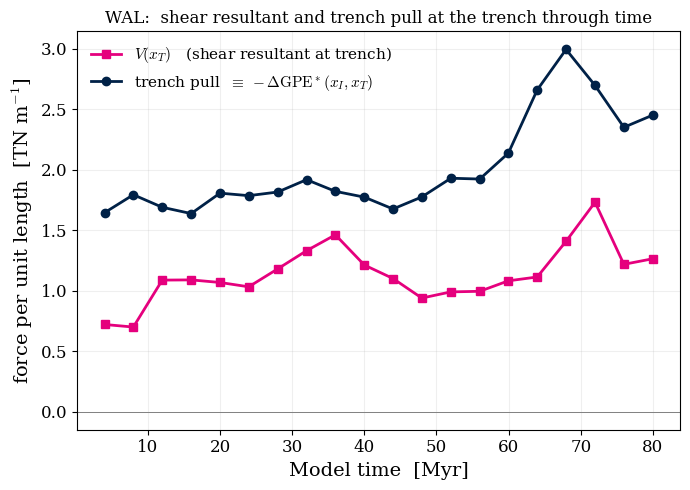

In [62]:
# Wrap-up slide figure: V(t) and trench pull at the trench column through time.
# Distilled from the 3-panel time-evolution figure: drops F_D(x_T), w_T,
# ΔF_D, and keeps only the two curves that land the slide's punchline —
# V(x_T) > 0 throughout (downward shear resultant), and the trench pull
# (= −ΔGPE*) is positive and of order a few TN/m throughout.

t_Myr = records['t_yr'] / 1e6

fig, ax = plt.subplots(figsize=(7, 5))

# V at trench — positive throughout the run (the shear resultant on a plane
# beneath the trench, sense: downward into the asthenosphere).
ax.plot(t_Myr, -records['V_xT'] * 1e-12, '-s',
        color='#E5007D', ms=6, lw=2.0,
        label=r'$V(x_T)$   (shear resultant at trench)')

# Trench pull = -ΔGPE*  (column-difference between x_T and x_I,
# equivalently Δσ̄_zz; relates to ΔP_T · z_np by the static scaling).
ax.plot(t_Myr, records['delta_GPE'] * 1e-12, '-o',
        color='#002147', ms=6, lw=2.0,
        label=r'trench pull  $\equiv\;-\Delta\mathrm{GPE}^*(x_I,x_T)$')

ax.axhline(0, color='0.5', lw=0.7)
ax.set_xlabel('Model time  [Myr]', fontsize=14)
ax.set_ylabel(r'force per unit length  [TN m$^{-1}$]', fontsize=14)
ax.legend(frameon=False, loc='upper left', fontsize=11)
ax.grid(alpha=0.20)
ax.tick_params(labelsize=12)

ax.set_title(f'{MODEL_KEY}:  shear resultant and trench pull at the trench through time',
             fontsize=12)

fig.tight_layout()

figures_dir = Path("figures"); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'V_dGPE_trench_time_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=220)
plt.show()


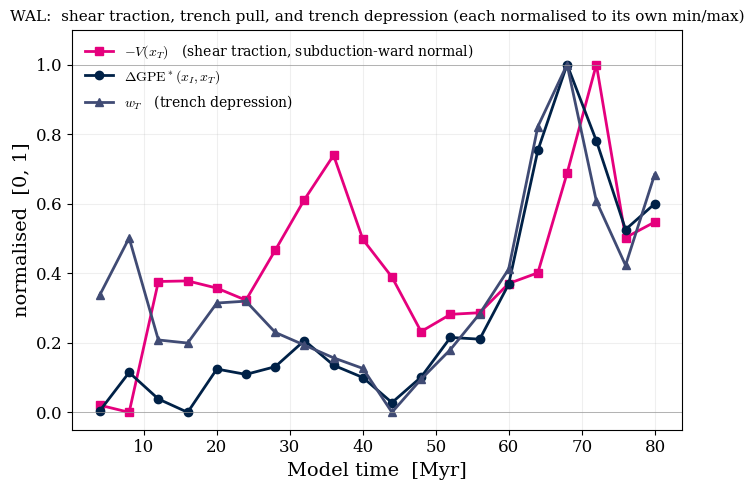

In [63]:
# Wrap-up slide figure (normalised version, sign-corrected):
# −V(t), ΔGPE*(t), and trench depression w_T(t) — each rescaled
# linearly to [0, 1] over its own (min, max) range so the three
# curves are visually overlaid.
#
# Sign convention:
#   −V(x_T) — V multiplied by −1 to read as the shear traction on a
#             vertical plane whose outward normal points in the
#             subduction direction (subduction-ward = "left-negative").
#   ΔGPE*   — column difference (x_I − x_T) plotted directly, no flip.
#   w_T     — trench-relative topography, naturally positive
#             (= fs[0, x_I] − fs[0, x_T]).

def _norm01(arr):
    """Linear rescale to [0, 1]:  0 ← arr.min(),  1 ← arr.max()."""
    arr = np.asarray(arr, dtype=float)
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    return (arr - lo) / (hi - lo) if hi > lo else np.zeros_like(arr)

t_Myr = records['t_yr'] / 1e6

mV_norm = _norm01(-records['V_xT'])           # shear traction, subduction-ward normal
GPE_norm = _norm01(records['delta_GPE'])      # ΔGPE* directly, no sign flip
wT_norm = _norm01(records['w_T'])             # trench depression

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(t_Myr, mV_norm,  '-s', color='#E5007D', ms=6, lw=2.0,
        label=r'$-V(x_T)$   (shear traction, subduction-ward normal)')
ax.plot(t_Myr, GPE_norm, '-o', color='#002147', ms=6, lw=2.0,
        label=r'$\Delta\mathrm{GPE}^*(x_I,x_T)$')
ax.plot(t_Myr, wT_norm,  '-^', color='#404B74', ms=6, lw=2.0,
        label=r'$w_T$   (trench depression)')

ax.axhline(0, color='0.6', lw=0.5)
ax.axhline(1, color='0.6', lw=0.5)
ax.set_xlabel('Model time  [Myr]', fontsize=14)
ax.set_ylabel('normalised  [0, 1]', fontsize=14)
ax.set_ylim(-0.05, 1.10)
ax.legend(frameon=False, loc=2, fontsize=10)
ax.grid(alpha=0.20)
ax.tick_params(labelsize=12)

ax.set_title(f'{MODEL_KEY}:  shear traction, trench pull, and trench depression '
             f'(each normalised to its own min/max)',
             fontsize=11)

fig.tight_layout()

figures_dir = Path("figures"); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'wrapup_normalised_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=220)
plt.show()


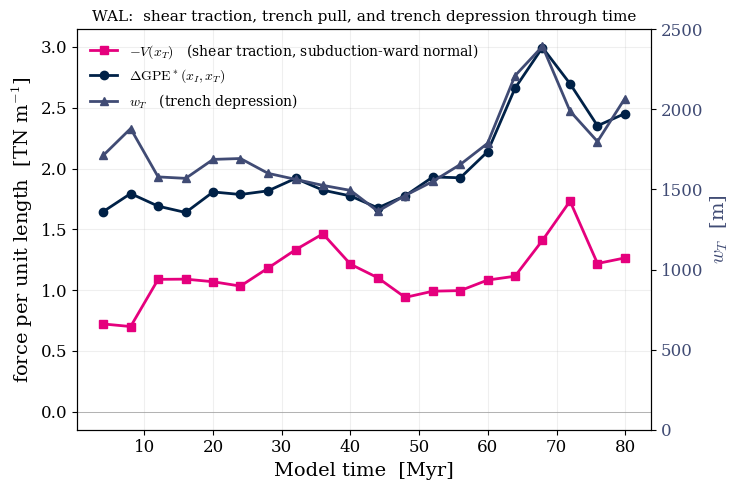

In [64]:
# Wrap-up slide figure (un-normalised, dual-axis):
#   left axis  — -V(x_T) and ΔGPE*(x_I, x_T)  in TN/m
#   right axis — w_T  (trench depression)     in m
#
# Sign convention: V negated to read as the shear traction on a vertical
# plane with subduction-ward normal; ΔGPE* and w_T plotted as recorded.

t_Myr = records['t_yr'] / 1e6

fig, ax = plt.subplots(figsize=(7.5, 5))
ax_r = ax.twinx()                    # right-hand axis for w_T

# Left axis — force per unit length (TN/m)
l1, = ax.plot(t_Myr, -records['V_xT']     * 1e-12, '-s',
              color='#E5007D', ms=6, lw=2.0,
              label=r'$-V(x_T)$   (shear traction, subduction-ward normal)')
l2, = ax.plot(t_Myr,  records['delta_GPE'] * 1e-12, '-o',
              color='#002147', ms=6, lw=2.0,
              label=r'$\Delta\mathrm{GPE}^*(x_I, x_T)$')

ax.axhline(0, color='0.6', lw=0.5)
ax.set_xlabel('Model time  [Myr]', fontsize=14)
ax.set_ylabel(r'force per unit length  [TN m$^{-1}$]', fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(alpha=0.20)

# Right axis — trench depression w_T (m)
l3, = ax_r.plot(t_Myr, records['w_T'], '-^',
                color='#404B74', ms=6, lw=2.0,
                label=r'$w_T$   (trench depression)')
ax_r.set_ylabel(r'$w_T$  [m]', fontsize=14, color='#404B74')
ax_r.tick_params(axis='y', labelsize=12, labelcolor='#404B74')
ax_r.set_ylim(0, 2500)

# Combined legend, upper-left
ax.legend(handles=[l1, l2, l3], frameon=False,
          loc='upper left', fontsize=10)

ax.set_title(f'{MODEL_KEY}:  shear traction, trench pull, and trench depression through time',
             fontsize=11)

fig.tight_layout()

figures_dir = Path("figures"); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'wrapup_dual_axis_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=220)
plt.show()


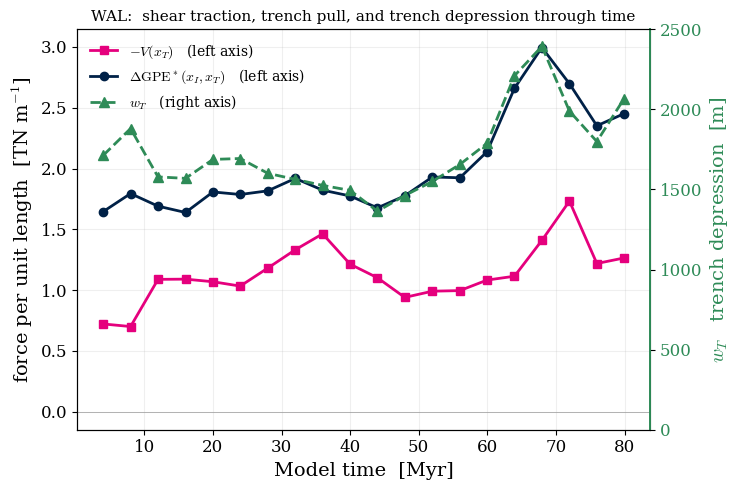

In [65]:
# Wrap-up slide figure (un-normalised, dual-axis) — visual rules to flag
# left- vs right-axis quantities at a glance:
#
#   * Left  axis  (force per unit length, TN/m): SOLID lines, square/circle
#                                                markers, "force" colours.
#   * Right axis  (topography, m):              DASHED line, triangle marker,
#                                                a distinct sea-green colour
#                                                that doesn't share the
#                                                navy/slate family.
#   * Right axis label, ticks, and spine all coloured to match the curve.
#   * Legend labels carry explicit "(left)" / "(right)" tags.
#
# Sign convention unchanged: V negated; ΔGPE* and w_T plotted as recorded.

t_Myr = records['t_yr'] / 1e6

# Palette — left-axis force curves stay in the brand navy/magenta family;
# right-axis topography curve gets a distinct sea green.
COLOR_V    = '#E5007D'   # magenta — left axis (force)
COLOR_GPE  = '#002147'   # navy    — left axis (force)
COLOR_WT   = '#2E8B57'   # sea green — right axis (topography)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax_r = ax.twinx()

# --- Left axis: force resultants (solid, square/circle) -------------------
l1, = ax.plot(t_Myr, -records['V_xT']     * 1e-12, '-s',
              color=COLOR_V,   ms=6, lw=2.0)
l2, = ax.plot(t_Myr,  records['delta_GPE'] * 1e-12, '-o',
              color=COLOR_GPE, ms=6, lw=2.0)

ax.axhline(0, color='0.6', lw=0.5)
ax.set_xlabel('Model time  [Myr]', fontsize=14)
ax.set_ylabel(r'force per unit length  [TN m$^{-1}$]', fontsize=14)
ax.tick_params(labelsize=12)
ax.grid(alpha=0.20)

# --- Right axis: trench topography (dashed, triangle, sea green) ---------
l3, = ax_r.plot(t_Myr, records['w_T'], '--^',
                color=COLOR_WT, ms=7, lw=2.0)

ax_r.set_ylabel(r'$w_T$   trench depression  [m]',
                fontsize=14, color=COLOR_WT)
ax_r.tick_params(axis='y', labelsize=12, labelcolor=COLOR_WT)
ax_r.spines['right'].set_color(COLOR_WT)
ax_r.spines['right'].set_linewidth(1.4)
ax_r.set_ylim(0, 2500)

# --- Combined legend (upper left) with explicit axis tags ----------------
ax.legend(
    handles=[l1, l2, l3],
    labels=[
        r'$-V(x_T)$   (left axis)',
        r'$\Delta\mathrm{GPE}^*(x_I, x_T)$   (left axis)',
        r'$w_T$   (right axis)',
    ],
    loc='upper left', frameon=False, fontsize=10,
)

ax.set_title(f'{MODEL_KEY}:  shear traction, trench pull, and trench depression through time',
             fontsize=11)

fig.tight_layout()

figures_dir = Path("figures"); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'wrapup_dual_axis_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=220)
plt.show()


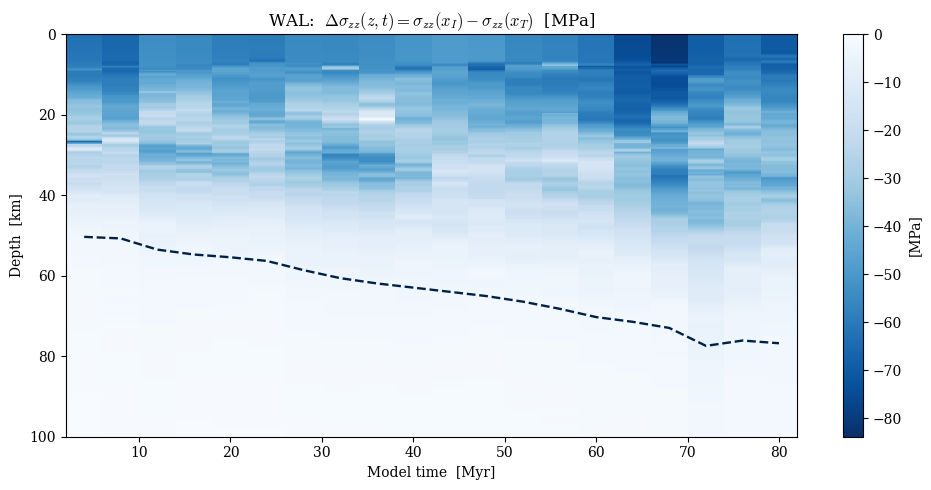

In [66]:
# Δσ_zz(z, t) — depth-by-time heat map
fig, ax = plt.subplots(figsize=(10, 5))
vmax = np.nanmax(np.abs(delta_sig_zz_zt)) * 1e-6
im = ax.pcolormesh(t_Myr, z_axis * 1e-3, delta_sig_zz_zt.T * 1e-6,
                   shading='auto', cmap='Blues_r', vmin=-vmax, vmax=0)

ax.plot(records['t_yr'] / 1e6, records['z_iso'] * 1e-3,
        '--', color='#002147', ms=5, lw=1.7, label="depth T_900")

ax.invert_yaxis()
ax.set_xlabel('Model time  [Myr]')
ax.set_ylabel('Depth  [km]')
ax.set_title(rf'{MODEL_KEY}:  $\Delta \sigma_{{zz}}(z, t) = \sigma_{{zz}}(x_I) - \sigma_{{zz}}(x_T)$  [MPa]')
fig.colorbar(im, ax=ax, label='[MPa]')
fig.tight_layout()
fig.savefig(figures_dir / f'time_evolution_dsigzz_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)

#ax.set
plt.show()

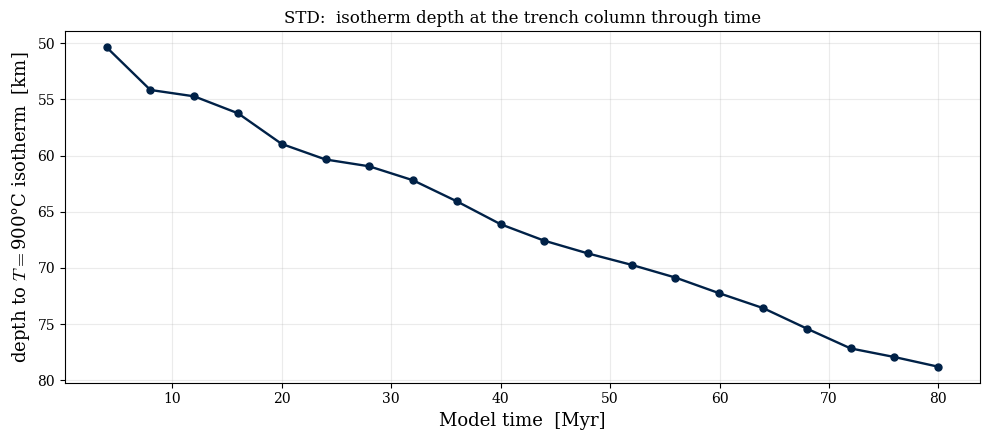

In [47]:
# Depth to the T_ISO isotherm at the trench column over time.
# Tracks how the thermal lithosphere thickness evolves under the trench.

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(records['t_yr'] / 1e6, records['z_iso'] * 1e-3,
        '-o', color='#002147', ms=5, lw=1.7)
ax.invert_yaxis()
ax.set_xlabel('Model time  [Myr]', fontsize=13)
ax.set_ylabel(f'depth to $T = ${T_ISO_K-273.15:.0f}°C isotherm  [km]', fontsize=13)
ax.set_title(f'{MODEL_KEY}:  isotherm depth at the trench column through time')
ax.grid(alpha=0.25)

fig.tight_layout()
figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f'time_evolution_z_iso_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=200)
plt.show()


In [35]:
#records

In [36]:
records['z_iso']

array([89837.86426133, 96532.84135946, 98649.53691056,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan,
                  nan,            nan,            nan,            nan])